In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [4]:
data = pd.read_csv("churn.csv")
data["TypeOfContract"] = data["Contract"] # Giving the column a more significant name.
data = data.drop("Contract", axis=1)
data.info()
data
# Data integrity assessment :
# SeniorCitizen is an encoded categorical variable : Yes -> 1 , No -> 0
# All data types seem to be accurate and relevant to the associated features
# Some categorical features might need to be encoded for some other analysis such as correlation 
# ----------------------- Understanding what the grain represents, what one columns represents from a business perspective -------------





<class 'pandas.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7050 non-null   str    
 1   gender           7050 non-null   str    
 2   SeniorCitizen    7050 non-null   int64  
 3   Partner          7050 non-null   str    
 4   Dependents       7050 non-null   str    
 5   tenure           7050 non-null   int64  
 6   PhoneService     7050 non-null   str    
 7   InternetService  7050 non-null   str    
 8   PaymentMethod    7050 non-null   str    
 9   MonthlyCharges   6841 non-null   float64
 10  TotalCharges     6839 non-null   float64
 11  Churn            7050 non-null   str    
 12  TypeOfContract   7050 non-null   str    
dtypes: float64(2), int64(2), str(9)
memory usage: 716.1 KB


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TypeOfContract
0,CUST1,Male,0,Yes,No,16,Yes,Fiber optic,Mailed check,74.44,1285.00,No,Month-to-month
1,CUST2,Female,0,No,No,57,Yes,Fiber optic,Mailed check,3.18,249.00,No,Two year
2,CUST3,Male,1,Yes,Yes,57,Yes,DSL,Electronic check,20.01,1135.63,No,Month-to-month
3,CUST4,Male,0,No,Yes,56,Yes,Fiber optic,Electronic check,89.88,5061.70,No,Month-to-month
4,CUST5,Male,1,Yes,Yes,6,Yes,No,Electronic check,95.17,678.35,No,One year
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,CUST1972,Male,0,No,Yes,69,Yes,Fiber optic,Mailed check,22.92,1536.78,No,Month-to-month
7046,CUST5308,Male,0,No,Yes,12,Yes,Fiber optic,Mailed check,87.95,1087.11,No,One year
7047,CUST4841,Female,0,Yes,Yes,65,Yes,No,Mailed check,61.66,4035.88,Yes,Two year
7048,CUST4522,Male,0,No,Yes,26,Yes,Fiber optic,Electronic check,67.58,1668.12,No,Month-to-month


Text(0.5, 1.0, 'How many of our clients are seniors ?')

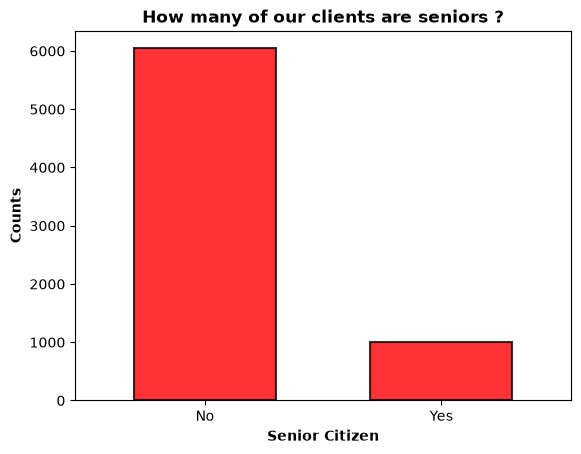

In [5]:

data["SeniorCitizen"].value_counts().plot(
    kind='bar',                                      
    color="red",
    edgecolor="black",  
    linewidth=1.5,
    width=0.6,
    alpha=0.8

                                          )

plt.xticks(
    ticks=[0, 1],
    labels=["No", "Yes"]
)
plt.xticks(rotation=360)
plt.xlabel("Senior Citizen", fontweight="bold")
plt.ylabel("Counts", fontweight="bold")
plt.title("How many of our clients are seniors ?", fontweight="bold", color="black")

In [6]:
Nulls = data.isnull().sum()
data[data.columns[Nulls > 1]]

# are the nulls revealing an information or simply missing inputs
# They might be unpaid subscriptions which are worth considering.

,MonthlyCharges,TotalCharges
0,74.44,1285.00
1,3.18,249.00
2,20.01,1135.63
3,89.88,5061.70
4,95.17,678.35
...,...,...
7045,22.92,1536.78
7046,87.95,1087.11
7047,61.66,4035.88
7048,67.58,1668.12


Text(0.5, 1.0, 'Monthly Charges Distribution')

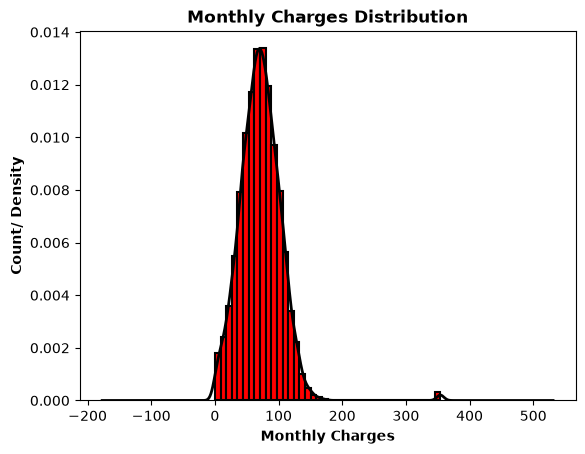

In [7]:
from scipy import stats
data["MonthlyCharges"].plot(kind="hist", bins=40, edgecolor="black", color="red", density=True, linewidth=1.5).plot(kind="kde", color="black")
# a bit skewed to the righ
data["MonthlyCharges"].plot(kind="kde", color="black", linewidth=2)
plt.xlabel("Monthly Charges", fontweight="bold")
plt.ylabel("Count/ Density", fontweight="bold")
plt.title("Monthly Charges Distribution", fontweight="bold")

# almost normally, with a 

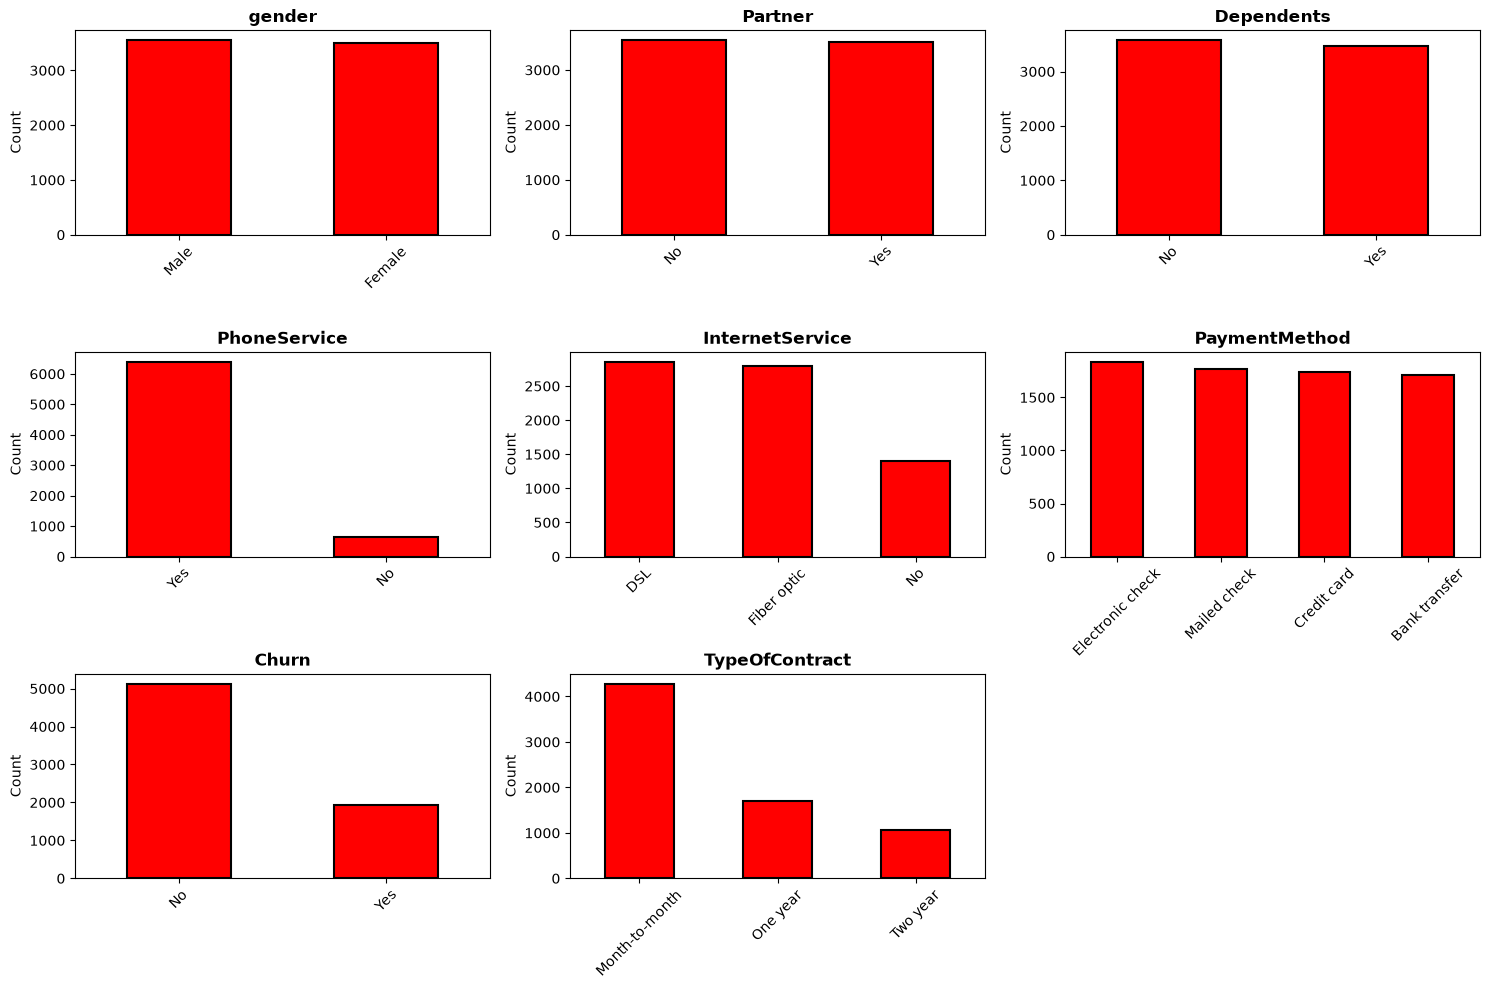

In [25]:

cat_cols = [col for col in data.select_dtypes(include="str").columns
            if col != "customerID"]


fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()


for ax, col in zip(axes, cat_cols):
    data[col].value_counts().plot(
        kind="bar",
        ax=ax,
        color="red",
        edgecolor="black",
        linewidth=1.5
    )
    
    ax.set_title(
        col,
        fontweight="bold",
        fontsize=12,
        color="black"
    )

    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Hide remaining empty axes
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


    



